In [ ]:
import zipfile
import os
import cv2
import numpy as np
import pandas as pd
import random
import tensorflow as tf
from skimage.metrics import structural_similarity as ssim
from tensorflow.keras.applications import InceptionV3
from tensorflow.keras.layers import LSTM, Dense, Dropout, TimeDistributed, GlobalAveragePooling2D
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Nadam
from sklearn.model_selection import train_test_split
from sklearn.utils.class_weight import compute_class_weight
from tensorflow.keras.callbacks import EarlyStopping
import matplotlib.pyplot as plt

In [ ]:
# Global Constants
NUM_FRAMES = 20  # [60,50,40,30,20,10]             # Number of frames to sample per video
MIN_FRAMES = 120                  # Minimum frames required in a video
max_frames = 120                  # Maximum frames allowed in a video
IMAGE_HEIGHT, IMAGE_WIDTH = 224, 224  # Target frame dimensions
SSIM_THRESHOLD = 0.80 #0.94             # Max SSIM allowed between selected frames
NUM_SHUFFLES = 6 #5 #6

In [ ]:
# GOOGLE DRIVE SETUP
from google.colab import drive
drive.mount('drive')

zip_folder = 'drive/My Drive/Colab Notebooks_videoAnalytics/all_phs1_phs6lv1_lv38_vids.zip'
extract_path = ''

with zipfile.ZipFile(zip_folder, 'r') as zip_ref:
    zip_ref.extractall(extract_path)

print("Extraction complete.")

Drive already mounted at drive; to attempt to forcibly remount, call drive.mount("drive", force_remount=True).
Extraction complete.


In [ ]:
#checking the contents extracted from the zip file
!ls all_phs1_phs6lv1_lv38_vids/

larvae_temp,24_4°C,15-10-2024,12-26-27PM.mp4
larvae_temp,24_4°C,15-10-2024,12-27-37PM.mp4
larvae_temp,24_4°C,15-10-2024,12-27-45PM.mp4
larvae_temp,24_5°C,15-10-2024,12-25-56PM.mp4
larvae_temp,24_5°C,15-10-2024,12-26-51PM.mp4
larvae_temp,24_5°C,15-10-2024,12-26-58PM.mp4
larvae_temp,24_5°C,15-10-2024,12-27-14PM.mp4
larvae_temp,24_5°C,15-10-2024,12-27-29PM.mp4
larvae_temp,24_5°C,15-10-2024,12-28-00PM.mp4
larvae_temp,24_6°C,14-10-2024,03-03-25PM.mp4
larvae_temp,24_6°C,14-10-2024,03-05-37PM.mp4
larvae_temp,24_6°C,14-10-2024,04-31-17PM.mp4
larvae_temp,24_6°C,15-10-2024,12-26-43PM.mp4
larvae_temp,24_6°C,15-10-2024,12-28-08PM.mp4
larvae_temp,24_6°C,15-10-2024,12-35-58PM.mp4
larvae_temp,24_6°C,15-10-2024,12-36-05PM.mp4
larvae_temp,24_7°C,14-10-2024,03-03-49PM.mp4
larvae_temp,24_7°C,14-10-2024,03-04-12PM.mp4
larvae_temp,24_7°C,14-10-2024,03-05-30PM.mp4
larvae_temp,24_7°C,14-10-2024,04-28-44PM.mp4
larvae_temp,24_7°C,14-10-2024,04-29-13PM.mp4
larvae_temp,24_7°C,14-10-2024,04-29-52PM.mp4
larvae_tem

In [ ]:
# count the number of videos in phs1_IoT_combinedVid
video_count = len(os.listdir('all_phs1_phs6lv1_lv38_vids'))
print(f"Number of videos in the folder: {video_count}")

Number of videos in the folder: 1351


In [ ]:
#import excel metadata
metadata_file = pd.read_excel('all_phs1_phs6lv1_lv38_vids_meta_data.xlsx')

In [ ]:
#display contents of metadata excel file
metadata_file

,larvae_Id,video_name,tag
0,LV_1,"larvae_temp,25_0°C,14-10-2024,02-32-12PM.mp4",positive
1,NaN,"larvae_temp,25_1°C,14-10-2024,02-32-21PM.mp4",positive
2,NaN,"larvae_temp,25_0°C,14-10-2024,02-32-29PM.mp4",positive
3,NaN,"larvae_temp,25_0°C,14-10-2024,02-32-37PM.mp4",positive
4,NaN,"larvae_temp,25_0°C,14-10-2024,02-32-44PM.mp4",positive
...,...,...,...
1346,NaN,"larvae_temp,27_1°C,03-07-2025,02-47-47PM.mp4",negative
1347,NaN,"larvae_temp,26_9°C,03-07-2025,02-47-54PM.mp4",negative
1348,NaN,"larvae_temp,27_0°C,03-07-2025,02-48-02PM.mp4",negative
1349,NaN,"larvae_temp,27_0°C,03-07-2025,02-48-10PM.mp4",negative


In [ ]:
# metadata_file.info()

In [ ]:
metadata_file.shape

(1351, 3)

In [ ]:
# FRAME PREPROCESSING
def preprocess_frame(frame, target_size=(IMAGE_WIDTH, IMAGE_HEIGHT)):
    """
    Center crop, resize, and normalize a frame for model input.
    Args:
        frame (np.ndarray): Raw BGR frame from video.
        target_size (tuple): (width, height) for resizing.
    Returns:
        np.ndarray: Preprocessed frame normalized to [0,1].
    """
    h, w = frame.shape[:2]
    min_dim = min(h, w)
    start_x = (w - min_dim) // 2
    start_y = (h - min_dim) // 2
    cropped_frame = frame[start_y:start_y + min_dim, start_x:start_x + min_dim]
    frame_resized = cv2.resize(cropped_frame, target_size)
    return frame_resized  # leave as 0-255 for SSIM selection

In [ ]:
def extract_all_frames(video_path, max_frames):
    """
    Extracts up to `max_frames` frames from a video.
    Returns array of frames (0-255, dtype=uint8).
    """
    cap = cv2.VideoCapture(video_path)
    frames = []
    frame_count = 0

    while frame_count < max_frames:
        ret, frame = cap.read()
        if not ret:
            break
        frame = preprocess_frame(frame)
        frames.append(frame)
        frame_count += 1

    cap.release()
    frames_array = np.array(frames)
    print(f"Extracted {len(frames_array)} frames from {video_path}. Target: {max_frames}")
    return frames_array

In [ ]:
def segment_frames(frames, num_segments=NUM_FRAMES):
    """
    Divide frames into equal segments for SSIM sampling.
    """
    total_frames = len(frames)
    segments = np.array_split(np.arange(total_frames), num_segments)
    print("Segments (frame index ranges):")
    for i, seg in enumerate(segments):
        print(f" Segment {i}: {seg}")
    return segments

In [ ]:
def sample_diverse_frames(frames, segments, ssim_threshold=SSIM_THRESHOLD):
    """
    Selects diverse frames per segment using SSIM, with bootstrapping.
    Returns selected frames array or None if failed.
    """
    selected_frames = []
    prev_gray = None

    for seg_idx, segment in enumerate(segments):
        print(f"\nSegment {seg_idx} original indices: {segment}")
        shuffled_sets = [np.random.choice(segment, size=len(segment), replace=True) for _ in range(NUM_SHUFFLES)]
        for shuffle_idx, s in enumerate(shuffled_sets):
            print(f"Segment {seg_idx} shuffle {shuffle_idx + 1} indices: {s}")
        all_candidates = np.concatenate(shuffled_sets)
        np.random.shuffle(all_candidates)

        best_frame = None
        best_similarity = 1.0
        fallback_frame = None
        fallback_similarity = 1.0

        for idx in all_candidates:
            frame = frames[idx]
            gray = cv2.cvtColor(frame.astype('uint8'), cv2.COLOR_BGR2GRAY)

            if prev_gray is None:
                selected_frames.append(frame)
                prev_gray = gray
                print(f"Segment {seg_idx}: Picked index {idx} (SSIM=N/A, first frame)")
                break

            similarity = ssim(prev_gray, gray, data_range=255) #changed gray.max() - gray.min()
            print(f"Segment {seg_idx}: SSIM(prev, frame[{idx}]) = {similarity:.4f}")

            if similarity < ssim_threshold:
                if similarity < best_similarity:
                    best_similarity = similarity
                    best_frame = (frame, gray, idx)
            else:
                if similarity < fallback_similarity:
                    fallback_similarity = similarity
                    fallback_frame = (frame, gray, idx)

        else:
            if best_frame:
                selected_frames.append(best_frame[0])
                prev_gray = best_frame[1]
                print(f"Segment {seg_idx}: Picked index {best_frame[2]} below threshold")
            elif fallback_frame:
                selected_frames.append(fallback_frame[0])
                prev_gray = fallback_frame[1]
                print(f"Segment {seg_idx}: Picked index {fallback_frame[2]} as fallback")
            else:
                print(f"Segment {seg_idx}: No valid frames found.")

    if len(selected_frames) == len(segments):

        # NORMALIZATION FOR InceptionV3 AFTER SSIM
        frames_array = np.array(selected_frames).astype("float32")
        frames_array = frames_array / 127.5 - 1  # [-1,1] normalization
        return frames_array
    else:
        print("Not enough diverse frames selected.")
        return None

In [ ]:
def load_video_data(data_path, metadata_file, num_frames=NUM_FRAMES):
    """
    Loads and processes videos into machine learning samples.
    Returns X (frame arrays) and y (binary labels)
    """
    metadata = pd.read_excel(metadata_file)
    X, y = [], []
    skipped_videos = []

    for _, row in metadata.iterrows():
        video_name = row['video_name']
        video_path = os.path.join(data_path, video_name)
        try:
            all_frames = extract_all_frames(video_path, max_frames)
            if all_frames is None or len(all_frames) < MIN_FRAMES:
                skipped_videos.append((video_name, "insufficient frames"))
                continue

            segments = segment_frames(all_frames, num_frames)
            sampled = sample_diverse_frames(all_frames, segments, SSIM_THRESHOLD)
            if sampled is not None:
                X.append(sampled)
                label = 1 if row['tag'].strip().lower() == 'positive' else 0
                y.append(label)
            else:
                skipped_videos.append((video_name, "SSIM sampling failed"))
        except Exception as e:
            skipped_videos.append((video_name, f"exception: {str(e)}"))

    print("\nSkipped videos summary:")
    for vid, reason in skipped_videos:
        print(f"- {vid}: {reason}")

    return np.array(X), np.array(y)

In [ ]:
# === MAIN EXECUTION ===
if __name__ == "__main__":
    data_path = 'all_phs1_phs6lv1_lv38_vids'
    metadata_file = 'all_phs1_phs6lv1_lv38_vids_meta_data.xlsx'

    print("Loading and preprocessing video data...")
    X, y = load_video_data(data_path, metadata_file)

    print("Shape of X after loading and normalization:", X.shape)
    print("Shape of y after loading:", y.shape)

    print("Saving preprocessed arrays...")
    np.save('X_prep_segments_20.npy', X)
    np.save('y_labels_segments_20.npy', y)

    print("Feature shape:", X.shape)
    print("Label shape:", y.shape)

Streaming output truncated to the last 5000 lines.
Segment 7: SSIM(prev, frame[47]) = 0.9949
Segment 7: SSIM(prev, frame[43]) = 0.9967
Segment 7: SSIM(prev, frame[45]) = 0.9956
Segment 7: SSIM(prev, frame[44]) = 0.9960
Segment 7: SSIM(prev, frame[45]) = 0.9956
Segment 7: SSIM(prev, frame[45]) = 0.9956
Segment 7: SSIM(prev, frame[43]) = 0.9967
Segment 7: SSIM(prev, frame[46]) = 0.9953
Segment 7: SSIM(prev, frame[46]) = 0.9953
Segment 7: SSIM(prev, frame[45]) = 0.9956
Segment 7: SSIM(prev, frame[44]) = 0.9960
Segment 7: SSIM(prev, frame[44]) = 0.9960
Segment 7: SSIM(prev, frame[44]) = 0.9960
Segment 7: SSIM(prev, frame[43]) = 0.9967
Segment 7: SSIM(prev, frame[43]) = 0.9967
Segment 7: SSIM(prev, frame[45]) = 0.9956
Segment 7: SSIM(prev, frame[45]) = 0.9956
Segment 7: SSIM(prev, frame[45]) = 0.9956
Segment 7: SSIM(prev, frame[45]) = 0.9956
Segment 7: SSIM(prev, frame[44]) = 0.9960
Segment 7: SSIM(prev, frame[45]) = 0.9956
Segment 7: SSIM(prev, frame[42]) = 0.9977
Segment 7: Picked index 4

In [ ]:
#print features
print("Features (X) shape:", X.shape)
print("Labels (y) shape:", y.shape)

Features (X) shape: (1351, 20, 224, 224, 3)
Labels (y) shape: (1351,)


In [ ]:
print(X)

[[[[[0.33333337 0.33333337 0.33333337]
    [0.3411765  0.3411765  0.3411765 ]
    [0.33333337 0.33333337 0.33333337]
    ...
    [0.38823533 0.36470592 0.38823533]
    [0.35686278 0.37254906 0.38823533]
    [0.35686278 0.37254906 0.38823533]]

   [[0.3411765  0.3411765  0.3411765 ]
    [0.3411765  0.3411765  0.3411765 ]
    [0.34901965 0.34901965 0.34901965]
    ...
    [0.38823533 0.38823533 0.4039216 ]
    [0.3803922  0.39607847 0.4039216 ]
    [0.35686278 0.37254906 0.38823533]]

   [[0.33333337 0.32549024 0.3411765 ]
    [0.3411765  0.33333337 0.34901965]
    [0.3411765  0.33333337 0.34901965]
    ...
    [0.37254906 0.39607847 0.39607847]
    [0.37254906 0.39607847 0.39607847]
    [0.36470592 0.38823533 0.38823533]]

   ...

   [[0.1686275  0.13725495 0.15294123]
    [0.16078436 0.12941182 0.15294123]
    [0.1686275  0.12941182 0.15294123]
    ...
    [0.2313726  0.24705887 0.28627455]
    [0.23921573 0.24705887 0.28627455]
    [0.22352946 0.2313726  0.27058828]]

   [[0.13725495 

In [ ]:
print(y)

[1 1 1 ... 0 0 0]


In [ ]:
SEED = 42
np.random.seed(SEED)
random.seed(SEED)
tf.random.set_seed(SEED)

In [ ]:
from sklearn.model_selection import train_test_split
from tensorflow.keras.utils import to_categorical

# Split data into training and validation sets
X_train, X_val, y_train, y_val = train_test_split(
    X, y,
    test_size=0.3,
    stratify=y,      # ensures class balance in splits
    random_state=SEED
)

In [ ]:
print("X_train shape:", X_train.shape)
print("X_val shape:", X_val.shape)
print("y_train shape:", y_train.shape)
print("y_val shape:", y_val.shape)

X_train shape: (945, 20, 224, 224, 3)
X_val shape: (406, 20, 224, 224, 3)
y_train shape: (945,)
y_val shape: (406,)


In [ ]:
# ONE-HOT ENCODING
# Since model output is 2 neurons + sigmoid(for binary), labels must be one-hot encoded
num_classes = 2
y_train_oh = to_categorical(y_train, num_classes=num_classes)
y_val_oh   = to_categorical(y_val, num_classes=num_classes)

print("y_train one-hot shape:", y_train_oh.shape)
print("y_val one-hot shape:", y_val_oh.shape)

y_train one-hot shape: (945, 2)
y_val one-hot shape: (406, 2)


In [ ]:
# FEATURE EXTRACTION USING InceptionV3
from tensorflow.keras.applications import InceptionV3
from tensorflow.keras.layers import GlobalAveragePooling2D
from tensorflow.keras.models import Model

base_model = InceptionV3(
    weights="imagenet",
    include_top=False,
    input_shape=(IMAGE_HEIGHT, IMAGE_WIDTH, 3)
)

87910968/87910968 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [ ]:
# FEATURE EXTRACTION USING InceptionV3
from tensorflow.keras.applications import InceptionV3
from tensorflow.keras.layers import GlobalAveragePooling2D
from tensorflow.keras.models import Model

base_model = InceptionV3(
    weights="imagenet",
    include_top=False,
    input_shape=(IMAGE_HEIGHT, IMAGE_WIDTH, 3)
)

# Apply global average pooling to reduce feature maps to a vector
global_avg_layer = GlobalAveragePooling2D()
feature_extractor = Model(inputs=base_model.input, outputs=global_avg_layer(base_model.output))

In [ ]:
# GRU-BASED MODEL DEFINITION
from tensorflow.keras.layers import Input, GRU, TimeDistributed, Dropout, Dense

# Define input layer for video sequences (NUM_FRAMES, HEIGHT, WIDTH, 3)
input_layer = Input(shape=(NUM_FRAMES, IMAGE_HEIGHT, IMAGE_WIDTH, 3))

# Extract frame-wise features using CNN (InceptionV3) applied to each frame
inception = TimeDistributed(feature_extractor)(input_layer)

# First GRU layer with 1024 units, returning sequences
gru_1 = GRU(1024, return_sequences=True)(inception)
dropout_1 = Dropout(0.5)(gru_1)

# Second GRU layer with 512 units
gru_2 = GRU(512)(dropout_1)
dropout_2 = Dropout(0.5)(gru_2)

# SINGLE DENSE LAYER (512 UNITS)-Fully connected dense layer
dense_1 = Dense(512, activation="relu")(dropout_2)
dropout_3 = Dropout(0.5)(dense_1)

# Output layer for binary classification-one-hot  (2 neurons + sigmoid)
output_layer = Dense(num_classes, activation="sigmoid")(dropout_3)

# Define/Build the model
model = Model(inputs=input_layer, outputs=output_layer)

In [ ]:
# COMPILE MODEL
optimizer = Nadam(learning_rate=1e-4) #try1e-5
model.compile(
    loss="categorical_crossentropy",
    optimizer=optimizer,
    metrics=["accuracy"])

In [ ]:
model.summary()

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_2 (InputLayer)      │ (None, 20, 224, 224,   │             0 │
│                                 │ 3)                     │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ time_distributed                │ (None, 20, 2048)       │    21,802,784 │
│ (TimeDistributed)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ gru (GRU)                       │ (None, 20, 1024)       │     9,443,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 20, 1024)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ gru_1 (GRU)                     │ (None, 512)            │     2,362,368 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 512)            │       262,656 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 2)              │         1,026 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 33,872,162 (129.21 MB)

 Trainable params: 33,837,730 (129.08 MB)

 Non-trainable params: 34,432 (134.50 KB)

In [ ]:
# EARLY STOPPING
from tensorflow.keras.callbacks import EarlyStopping

early_stopping = EarlyStopping(
    monitor="val_loss",    # Monitor validation loss
    patience=5,            # Stop if no improvement after 5 epochs
    restore_best_weights=True  # Restore best model weights
)

In [ ]:
# CALCULATE CLASS WEIGHTS
from sklearn.utils.class_weight import compute_class_weight
class_weights = compute_class_weight('balanced', classes=np.unique(y_train), y=y_train)
w0 = class_weights[0]
w1 = class_weights[1]

In [ ]:
# MODEL TRAINING
history = model.fit(
    X_train,
    y_train_oh,           # Use one-hot labels here
    epochs=10, #10 #5, #10,
    batch_size=5,
    class_weight={0: w0, 1: w1},
    callbacks=[early_stopping],
    validation_data=(X_val, y_val_oh)  # Validation labels also one-hot
)

Epoch 1/10
189/189 ━━━━━━━━━━━━━━━━━━━━ 665s 1s/step - accuracy: 0.6030 - loss: 0.7394 - val_accuracy: 0.7635 - val_loss: 0.6593
Epoch 2/10
189/189 ━━━━━━━━━━━━━━━━━━━━ 170s 898ms/step - accuracy: 0.7955 - loss: 0.5392 - val_accuracy: 0.8621 - val_loss: 0.3104
Epoch 3/10
189/189 ━━━━━━━━━━━━━━━━━━━━ 170s 899ms/step - accuracy: 0.8754 - loss: 0.3586 - val_accuracy: 0.8744 - val_loss: 0.3352
Epoch 4/10
189/189 ━━━━━━━━━━━━━━━━━━━━ 170s 899ms/step - accuracy: 0.8904 - loss: 0.2919 - val_accuracy: 0.8941 - val_loss: 0.2693
Epoch 5/10
189/189 ━━━━━━━━━━━━━━━━━━━━ 170s 900ms/step - accuracy: 0.9141 - loss: 0.2214 - val_accuracy: 0.8177 - val_loss: 0.4690
Epoch 6/10
189/189 ━━━━━━━━━━━━━━━━━━━━ 169s 897ms/step - accuracy: 0.8694 - loss: 0.3211 - val_accuracy: 0.8695 - val_loss: 0.3620
Epoch 7/10
189/189 ━━━━━━━━━━━━━━━━━━━━ 170s 900ms/step - accuracy: 0.9472 - loss: 0.1428 - val_accuracy: 0.8695 - val_loss: 0.4866
Epoch 8/10
189/189 ━━━━━━━━━━━━━━━━━━━━ 170s 900ms/step - accuracy: 0.9217 - lo

In [ ]:
# MODEL EVALUATION
loss, accuracy = model.evaluate(X_val, y_val_oh)
print(f"Validation Loss: {loss:.4f}")
print(f"Validation Accuracy: {accuracy:.4f}")


13/13 ━━━━━━━━━━━━━━━━━━━━ 6s 411ms/step - accuracy: 0.9134 - loss: 0.2630
Validation Loss: 0.2546
Validation Accuracy: 0.9187


In [ ]:
# CONFUSION MATRIX
from sklearn.metrics import confusion_matrix, classification_report
import numpy as np

# Predict probabilities
y_pred_prob = model.predict(X_val)

# Convert softmax probabilities to class labels
y_pred = np.argmax(y_pred_prob, axis=1)
y_true = np.argmax(y_val_oh, axis=1)

cm = confusion_matrix(y_true, y_pred)
print("Confusion Matrix:\n", cm)
print("Classification Report:\n", classification_report(y_true, y_pred))

13/13 ━━━━━━━━━━━━━━━━━━━━ 98s 4s/step
Confusion Matrix:
 [[183  20]
 [ 13 190]]
Classification Report:
               precision    recall  f1-score   support

           0       0.93      0.90      0.92       203
           1       0.90      0.94      0.92       203

    accuracy                           0.92       406
   macro avg       0.92      0.92      0.92       406
weighted avg       0.92      0.92      0.92       406



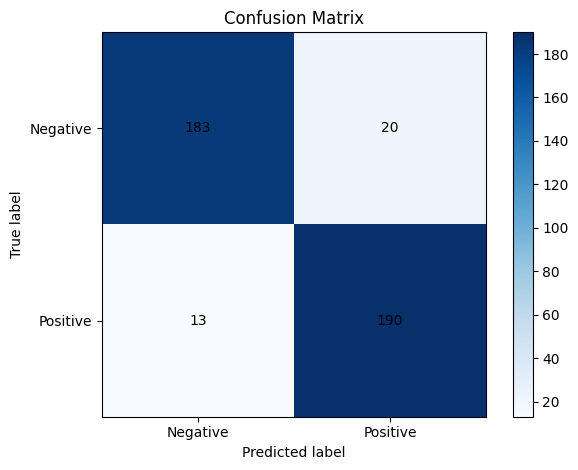

In [ ]:
# Plot confusion matrix
import matplotlib.pyplot as plt
plt.figure()
plt.imshow(cm, interpolation='nearest', cmap='Blues')
plt.title('Confusion Matrix')
plt.colorbar()
plt.xlabel('Predicted label')
plt.ylabel('True label')
ticks = np.arange(2)
plt.xticks(ticks, ['Negative','Positive'])
plt.yticks(ticks, ['Negative','Positive'])
for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        plt.text(j, i, cm[i, j], ha='center', va='center')
plt.tight_layout()
plt.savefig(f"confusion_matrix_segments_20.png") #save figure
plt.show()

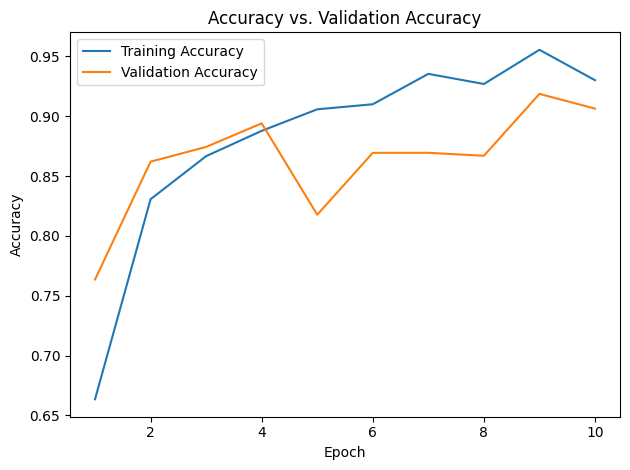

In [ ]:
# ACCURACY VS VALIDATION ACCURACY
accuracy     = history.history['accuracy']
val_accuracy = history.history['val_accuracy']
epochs       = range(1, len(accuracy) + 1)

plt.figure()
plt.plot(epochs, accuracy, label='Training Accuracy')
plt.plot(epochs, val_accuracy, label='Validation Accuracy')
plt.title('Accuracy vs. Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.tight_layout()
plt.savefig(f"accuracy_plot_segments_20.png") ##save figure
plt.show()

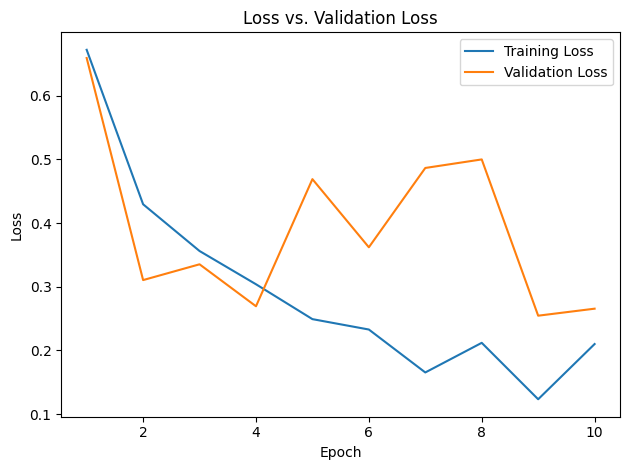

In [ ]:
# LOSS VS VALIDATION LOSS
loss      = history.history['loss']
val_loss  = history.history['val_loss']

plt.figure()
plt.plot(epochs, loss, label='Training Loss')
plt.plot(epochs, val_loss, label='Validation Loss')
plt.title('Loss vs. Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.tight_layout()
plt.savefig(f"loss_plot_segments_20.png") ##save figure
plt.show()

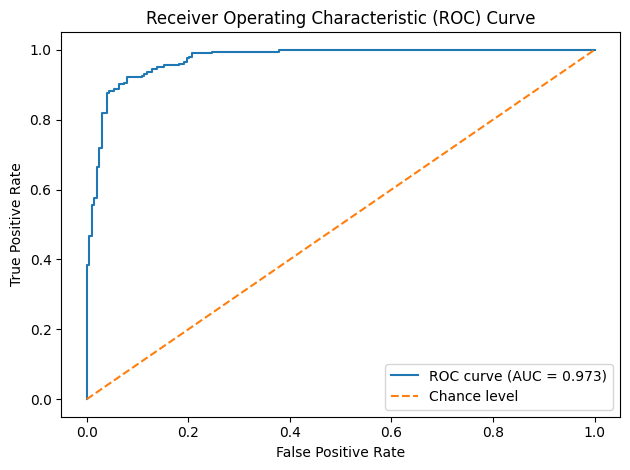

In [ ]:
# ROC CURVE
from sklearn.metrics import roc_curve, auc

# Compute ROC curve for positive class
fpr, tpr, thresholds = roc_curve(y_true, y_pred_prob[:,1])
roc_auc = auc(fpr, tpr)

plt.figure()
plt.plot(fpr, tpr, label=f'ROC curve (AUC = {roc_auc:.3f})')
plt.plot([0, 1], [0, 1], linestyle='--', label='Chance level')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve')
plt.legend(loc='lower right')
plt.tight_layout()
plt.savefig(f"roc_curve_segments_20.png") ##save figure
plt.show()

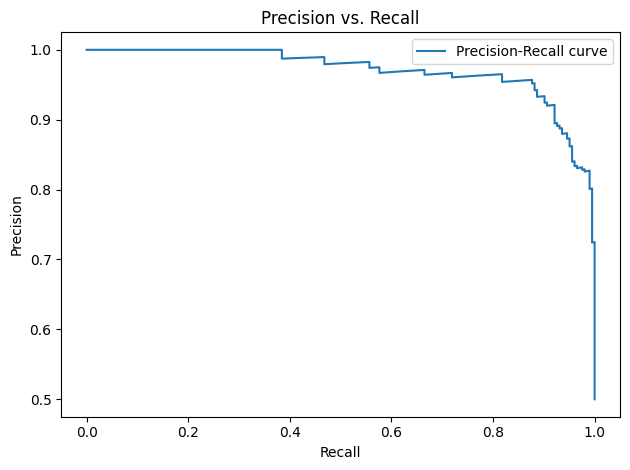

In [ ]:
# PRECISION-RECALL CURVE
from sklearn.metrics import precision_recall_curve

precision, recall, _ = precision_recall_curve(y_true, y_pred_prob[:,1])

plt.figure()
plt.plot(recall, precision, label='Precision-Recall curve')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision vs. Recall')
plt.legend()
plt.tight_layout()
plt.savefig(f"precision_recall_curve_segments_20.png") ##save figure
plt.show()

In [ ]:
# SAVE MODEL & WEIGHTS
model.save("InceptionV3_model_20.keras")
model.save("InceptionV3_model_20.h5")
print("Model saved successfully!")
model.save_weights("InceptionV3.weights_20.h5")
print("Model weights saved!")

Model saved successfully!
Model weights saved!


In [ ]:

# EXPERIMENT RESULTS TABLE FOR CURRENT SEGMENT CONFIGURATION
from sklearn.metrics import precision_score, recall_score, f1_score

# Calculate evaluation metrics
precision_val = precision_score(y_true, y_pred)
recall_val = recall_score(y_true, y_pred)
f1_val = f1_score(y_true, y_pred)

# Create results table
results_table = pd.DataFrame({
    "Segments": [NUM_FRAMES],
    #"Validation Accuracy": [accuracy],
    #"Validation Loss": [loss],
    "Precision": [precision_val],
    "Recall": [recall_val],
    "F1 Score": [f1_val],
    "ROC AUC": [roc_auc]
})

# Display table
print(f"\nExperiment Results Table: {NUM_FRAMES} Segments")
display(results_table)


Experiment Results Table: 20 Segments


,Segments,Precision,Recall,F1 Score,ROC AUC
0,20,0.904762,0.935961,0.920097,0.97287
